<a href="https://colab.research.google.com/github/LiNlIn4968/ResearchFig/blob/main/CMRR_PSRR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

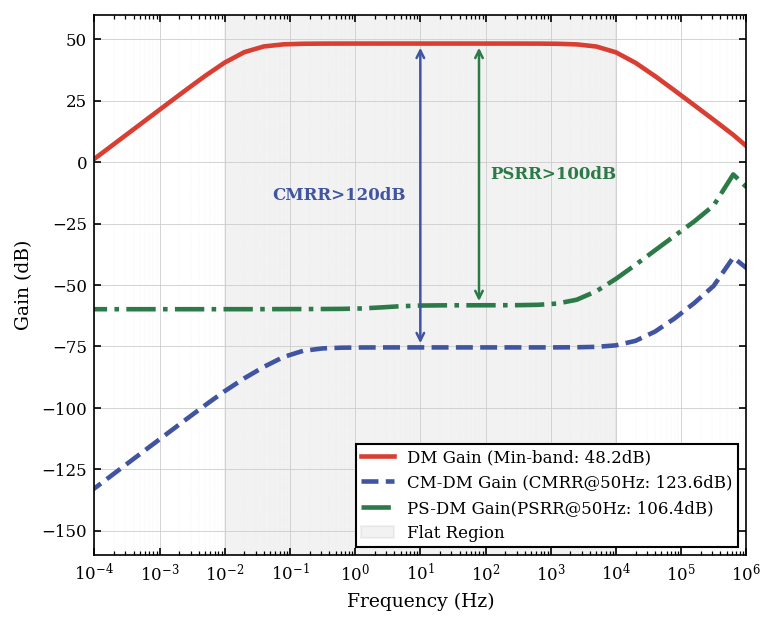

In [1]:
import pandas as pd  # 导入数据处理库
import matplotlib.pyplot as plt  # 导入绘图库
import numpy as np  # 导入数值计算库

# --- 1. IEEE 标准学术风格设置 ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['font.size'] = 9                  # 适合双栏排版的字号
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# 提高图像的DPI
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# --- 2. 加载与清洗数据 ---
file_path = 'amp_data.xlsx'
df = pd.read_excel(file_path)

freq = df.iloc[:, 0]
acm = df.iloc[:, 1]
adm = df.iloc[:, 5]
psrr = df.iloc[:, 7]

# --- 3. 创建画布 ---
fig, ax = plt.subplots(figsize=(5, 4))

# 绘制曲线
ax.semilogx(freq, adm, color='#d93e32', linewidth=2.2, label='DM Gain (Min-band: 48.2dB)')
ax.semilogx(freq, acm, color='#4054a1', linewidth=2.2, linestyle='--', label='CM-DM Gain (CMRR@50Hz: 123.6dB)')
ax.semilogx(freq, psrr, color='#2c7a47', linewidth=2.2, linestyle='-.', label='PS-DM Gain(PSRR@50Hz: 106.4dB)')

# --- 4. 标注 CMRR ---
ann_freq_cmrr = 10**1
idx_cmrr = (freq - ann_freq_cmrr).abs().idxmin()
ax.annotate('', xy=(freq[idx_cmrr], adm[idx_cmrr]), xytext=(freq[idx_cmrr], acm[idx_cmrr]),
            arrowprops=dict(arrowstyle='<->', color='#4054a1', lw=1.2))
ax.text(freq[idx_cmrr]*0.6, (adm[idx_cmrr] + acm[idx_cmrr])/2, 'CMRR>120dB',
        color='#4054a1', fontsize=8, fontweight='bold', va='center', ha='right')

# --- 5. 标注 PSRR ---
ann_freq_psrr = 10**2
idx_psrr = (freq - ann_freq_psrr).abs().idxmin()
ax.annotate('', xy=(freq[idx_psrr], adm[idx_psrr]), xytext=(freq[idx_psrr], psrr[idx_psrr]),
            arrowprops=dict(arrowstyle='<->', color='#2c7a47', lw=1.2))
ax.text(freq[idx_psrr]*1.5, (adm[idx_psrr] + psrr[idx_psrr])/2, 'PSRR>100dB',
        color='#2c7a47', fontsize=8, fontweight='bold', va='center')

ax.axvspan(1e-2, 1e4, color='gray', alpha=0.1, label='Flat Region')

# --- 6. 坐标轴设置 ---
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_xlim([1e-4, 1e6])
ax.set_ylim([-160, 60])
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.grid(True, which="major", linestyle='-', linewidth=0.4, color='0.8')
ax.grid(True, which="minor", linestyle=':', linewidth=0.2, color='0.9')

# --- 7. 图例与保存 ---
ax.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, framealpha=1, borderpad=0.3)
plt.tight_layout(pad=0.1)

# 保存多种格式
fig.savefig('plot.pdf', bbox_inches='tight')   # PDF (矢量)
fig.savefig('plot.svg', bbox_inches='tight')   # SVG (矢量)
fig.savefig('plot.eps', bbox_inches='tight')   # EPS (矢量)
fig.savefig('plot.png', dpi=300, bbox_inches='tight') # PNG (高清位图)

plt.show()